<a href="https://colab.research.google.com/github/jiyoungeeeeeeeeeeeeeeeeeeeee/twitter_psychopath/blob/main/nonparametric_statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/psychopath_data/PersonalityData_ExternalVersion001.csv')

In [6]:
data['Var20'] = pd.to_numeric(data['Var20'] , errors = 'coerce')
data = data.drop(['uid'] , axis = 1)
data = data.dropna(axis = 0)
data.drop_duplicates(inplace= True)

In [7]:
from scipy.stats import spearmanr
from sklearn.feature_selection import mutual_info_regression
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
spearman_scores = []
spearman_pvals = []

X = data.drop('psychopathy' , axis = 1)
y = data['psychopathy']

for col in X.columns:
  coef , p = spearmanr(X[col],y)
  spearman_scores.append(coef)
  spearman_pvals.append(p)

  print(f"{col} : score {coef} , p_values {p}")


machiavellianism : score 0.4218325775444724 , p_values 4.975639835123878e-107
narcissism : score 0.27733487064750767 , p_values 8.346363300806506e-45
openness : score 0.032716977542666115 , p_values 0.10424190247723641
conscientiousness : score -0.20422939505477233 , p_values 1.2221122125987857e-24
extraversion : score 0.08904494657413721 , p_values 9.452886925720853e-06
agreeableness : score -0.38570697445704494 , p_values 2.521392661608041e-88
neuroticism : score 0.09383459433042964 , p_values 3.032548391066683e-06
Var1 : score 0.05326666644625711 , p_values 0.008139330870860993
Var2 : score 0.06778070805190325 , p_values 0.0007550665345557849
Var3 : score 0.056739790698144985 , p_values 0.004816660851419674
Var4 : score 0.06659144661321524 , p_values 0.0009345551747073738
Var5 : score 0.06710846641484025 , p_values 0.0008521511855130996
Var6 : score 0.0691613512700661 , p_values 0.0005870150836954558
Var7 : score 0.06672249595873209 , p_values 0.000912997348919659
Var8 : score 0.047

In [9]:
mi_scores = mutual_info_regression(X,y)

for col , score in zip(X.columns , mi_scores):
  print(f"{col} : {score}")

machiavellianism : 0.12037855408945397
narcissism : 0.04451156738743656
openness : 0.0050251145665880514
conscientiousness : 0.03946310375495887
extraversion : 0.0
agreeableness : 0.12205562973395967
neuroticism : 0.0
Var1 : 0.0
Var2 : 0.02105532268721566
Var3 : 0.0
Var4 : 0.02638949849298733
Var5 : 0.0
Var6 : 0.0
Var7 : 0.005633703917268917
Var8 : 0.0193012674836055
Var9 : 0.04242757509674089
Var10 : 0.010176586647927088
Var11 : 0.0
Var12 : 0.016337727652198986
Var13 : 0.0
Var14 : 0.0
Var15 : 0.0
Var16 : 0.006348101821860297
Var17 : 0.015792728453964955
Var18 : 0.01791763618745712
Var19 : 0.02168397754156004
Var20 : 0.017055271766506674
Var21 : 0.0
Var22 : 0.0
Var23 : 0.0
Var24 : 0.0
Var25 : 0.00889999221285187
Var26 : 0.00893348901218527
Var27 : 0.00026248228392944384
Var28 : 0.0
Var29 : 0.03268820598804556
Var30 : 0.0
Var31 : 0.010574065213167394
Var32 : 0.0
Var33 : 0.009090233257857072
Var34 : 0.0
Var35 : 0.029856530484061672
Var36 : 0.0022658797566146305
Var37 : 0.0
Var38 : 0.0220

In [10]:
log_pvals = np.log(np.array(spearman_pvals) + 1e-10)

df_selected = pd.DataFrame({
    'features':X.columns,
    'MI_score':mi_scores,
    'spearman_score':spearman_scores,
    'spearman_pval': spearman_pvals,
    'log_pval': log_pvals
})

df_selected

,features,MI_score,spearman_score,spearman_pval,log_pval
0,machiavellianism,0.120379,0.421833,4.975640e-107,-23.025851
1,narcissism,0.044512,0.277335,8.346363e-45,-23.025851
2,openness,0.005025,0.032717,1.042419e-01,-2.261041
3,conscientiousness,0.039463,-0.204229,1.222112e-24,-23.025851
4,extraversion,0.000000,0.089045,9.452887e-06,-11.569180
...,...,...,...,...,...
102,Var96,0.000000,-0.038952,5.305840e-02,-2.936362
103,Var97,0.000000,-0.024751,2.191059e-01,-1.518200
104,Var98,0.000000,-0.050230,1.258935e-02,-4.374904
105,Var99,0.000000,0.018004,3.714085e-01,-0.990453


In [11]:
df_select = df_selected.copy()

scaler = MinMaxScaler()
df_select['MI_scaled'] = scaler.fit_transform(df_select[['MI_score']])
df_select['Spear_scaled'] = scaler.fit_transform(df_select[['spearman_score']].abs())


df_select['compose_score'] = df_select['MI_scaled'] * 0.5 + df_select['Spear_scaled']*0.5

df_sorted = df_select.sort_values(ascending= False , by = 'compose_score')['features']

top_compose = df_sorted.head(36)
top_compose

,features
0,machiavellianism
5,agreeableness
1,narcissism
3,conscientiousness
52,Var46
15,Var9
73,Var67
35,Var29
58,Var52
59,Var53


In [12]:
df_filter = data[top_compose.tolist() + ['psychopathy']]

In [13]:
df_filter

,machiavellianism,agreeableness,narcissism,conscientiousness,Var46,Var9,Var67,Var29,Var52,Var53,...,Var48,Var19,Var12,neuroticism,Var66,Var79,Var81,extraversion,Var7,psychopathy
0,3.4,3.5,3.444444,6.0,0.05,78.0,0.49,0.39,3.58,1.12,...,0.05,132.0,3227.0,3.5,1.41,1.58,1.01,5.5,112.0,2.444444
1,2.4,3.0,2.777778,4.5,0.06,24.0,0.82,0.36,2.85,0.83,...,0.16,58.0,3183.0,5.5,1.77,1.52,2.06,6.0,77.0,1.888889
2,3.0,6.5,3.444444,6.0,0.42,22.0,0.89,0.47,4.78,2.43,...,0.27,0.0,417.0,3.0,1.97,1.79,1.68,6.0,4.0,1.111111
3,3.0,6.5,2.444444,3.5,0.22,13.0,1.07,0.68,3.84,2.52,...,0.12,0.0,969.0,1.5,2.49,2.32,2.17,2.0,3.0,1.888889
4,3.1,5.5,1.333333,5.5,0.26,139.0,0.98,0.45,3.83,3.86,...,0.13,121.0,3165.0,5.0,2.53,1.14,1.42,2.5,45.0,2.111111
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2921,2.7,3.0,2.000000,5.5,0.43,5.0,1.30,0.22,3.24,2.16,...,0.00,1.0,37.0,4.0,2.81,1.73,2.38,5.5,2.0,2.000000
2922,2.4,3.5,3.222222,6.5,0.00,2.0,0.60,0.60,1.20,1.80,...,0.00,1.0,8.0,4.5,0.60,0.60,1.20,3.0,1.0,2.000000
2923,3.0,6.5,2.444444,4.5,0.00,2.0,0.00,1.90,3.81,6.67,...,0.00,0.0,7.0,1.0,0.95,1.90,0.00,7.0,1.0,1.333333
2924,3.6,5.0,3.666667,2.5,3.48,5.0,0.00,0.00,3.48,5.22,...,0.00,0.0,11.0,5.5,0.00,0.87,0.00,3.5,2.0,2.777778


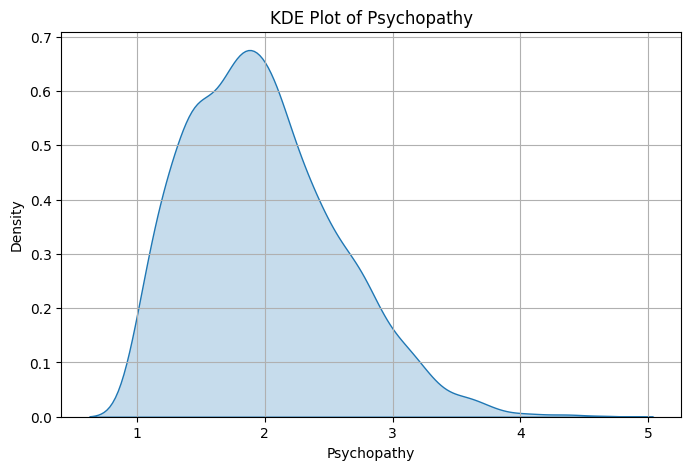

In [14]:
plt.figure(figsize=(8, 5))
sns.kdeplot(df_filter['psychopathy'], fill=True)
plt.title('KDE Plot of Psychopathy')
plt.xlabel('Psychopathy')
plt.ylabel('Density')
plt.grid(True)
plt.show()

# regression model

In [15]:
from xgboost import XGBRFRegressor
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.metrics import mean_squared_error , r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import shap

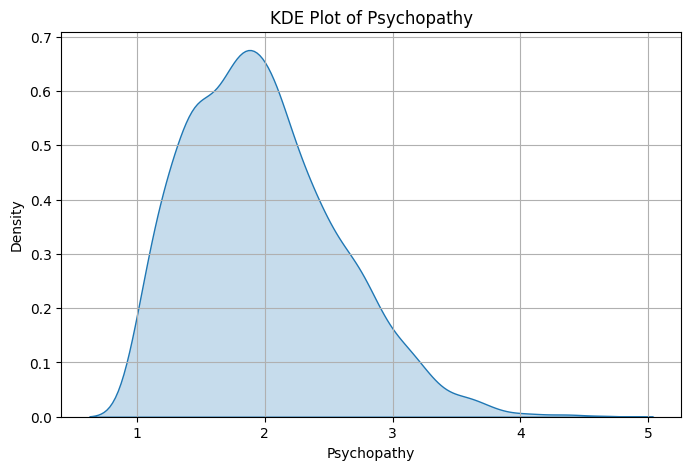

In [16]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data['psychopathy'], fill=True)
plt.title('KDE Plot of Psychopathy')
plt.xlabel('Psychopathy')
plt.ylabel('Density')
plt.grid(True)
plt.show()


In [17]:
X_train , X_test , y_train , y_test  = train_test_split(
    df_filter.drop('psychopathy' , axis =1),
    df_filter['psychopathy'],
    random_state = 42
)

In [18]:
xgb_reg = XGBRFRegressor(
    n_estimaters = 100,
    learning_rate = 0.1,
    max_depth = 4,
    randomm_state = 42
)

xgb_reg.fit(X_train , y_train)
y_xpred = xgb_reg.predict(X_test)


print('XGB RMSE:', np.sqrt(mean_squared_error(y_test, y_xpred)))
print('XGB R²:' , r2_score(y_test , y_xpred))

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:39:40] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "n_estimaters", "randomm_state" } are not used.

  warnings.warn(smsg, UserWarning)


XGB RMSE: 0.5826302982350027
XGB R²: 0.04704079207015577


In [19]:
model = RandomForestRegressor()

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'min_samples_leaf': [2, 4],
    'max_features': [10, 20]
}

grid = GridSearchCV(
    model,
    param_grid,
    cv=3,
    scoring='r2',
    verbose=2
)

grid.fit(X_train, y_train)

print(f"best params:{grid.best_params_}")
best_model = grid.best_estimator_

Fitting 3 folds for each of 16 candidates, totalling 48 fits
[CV] END max_depth=3, max_features=10, min_samples_leaf=2, n_estimators=100; total time=   0.7s
[CV] END max_depth=3, max_features=10, min_samples_leaf=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=3, max_features=10, min_samples_leaf=2, n_estimators=100; total time=   0.6s
[CV] END max_depth=3, max_features=10, min_samples_leaf=2, n_estimators=200; total time=   1.1s
[CV] END max_depth=3, max_features=10, min_samples_leaf=2, n_estimators=200; total time=   1.5s
[CV] END max_depth=3, max_features=10, min_samples_leaf=2, n_estimators=200; total time=   2.1s
[CV] END max_depth=3, max_features=10, min_samples_leaf=4, n_estimators=100; total time=   1.0s
[CV] END max_depth=3, max_features=10, min_samples_leaf=4, n_estimators=100; total time=   0.7s
[CV] END max_depth=3, max_features=10, min_samples_leaf=4, n_estimators=100; total time=   0.5s
[CV] END max_depth=3, max_features=10, min_samples_leaf=4, n_estimators=200

RF RMSE: 0.49778763715772983
RF R2: 0.3043730596031361


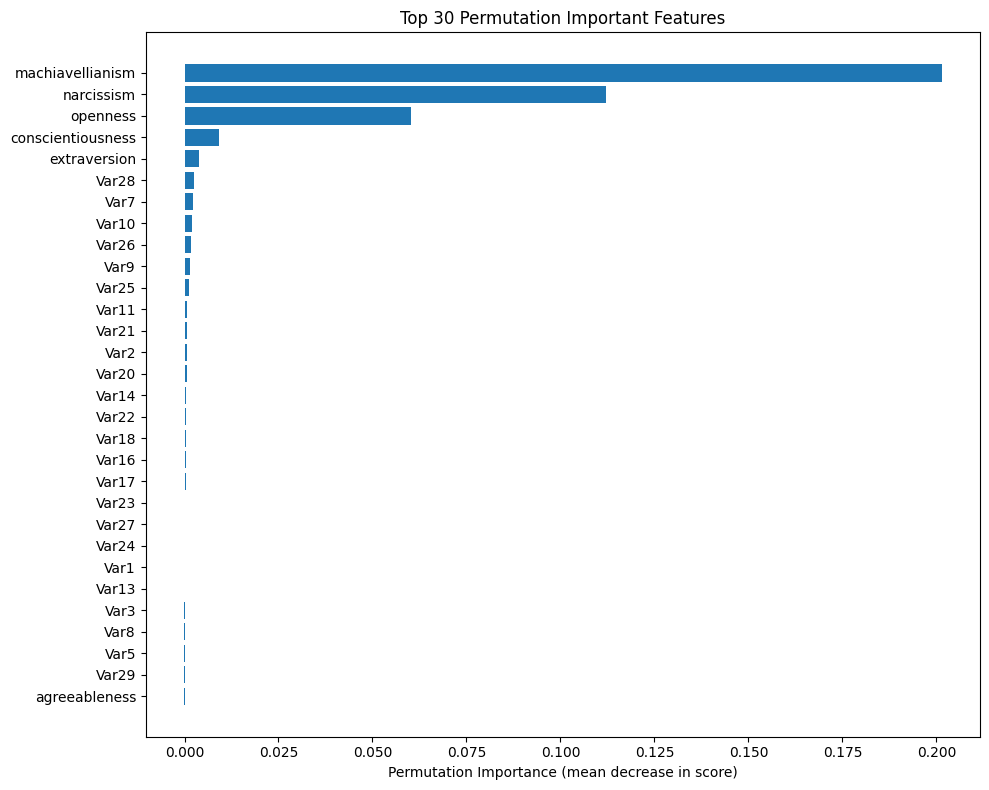

In [20]:
y_pred = best_model.predict(X_test)

print("RF RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("RF R2:", r2_score(y_test, y_pred))

perm = permutation_importance(best_model, X_test, y_test , n_repeats = 10)
top_idx = perm.importances_mean.argsort()[::-1][:30]


# 중요도와 feature 이름 정리
importances = perm.importances_mean[top_idx]
feature_names = X.columns[top_idx]

# DataFrame으로 정리 (선택)
perm_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=True)  # barh 위해 오름차순 정렬

# 시각화
plt.figure(figsize=(10, 8))
plt.barh(perm_df['feature'], perm_df['importance'])
plt.xlabel('Permutation Importance (mean decrease in score)')
plt.title('Top 30 Permutation Important Features')
plt.tight_layout()
plt.show()

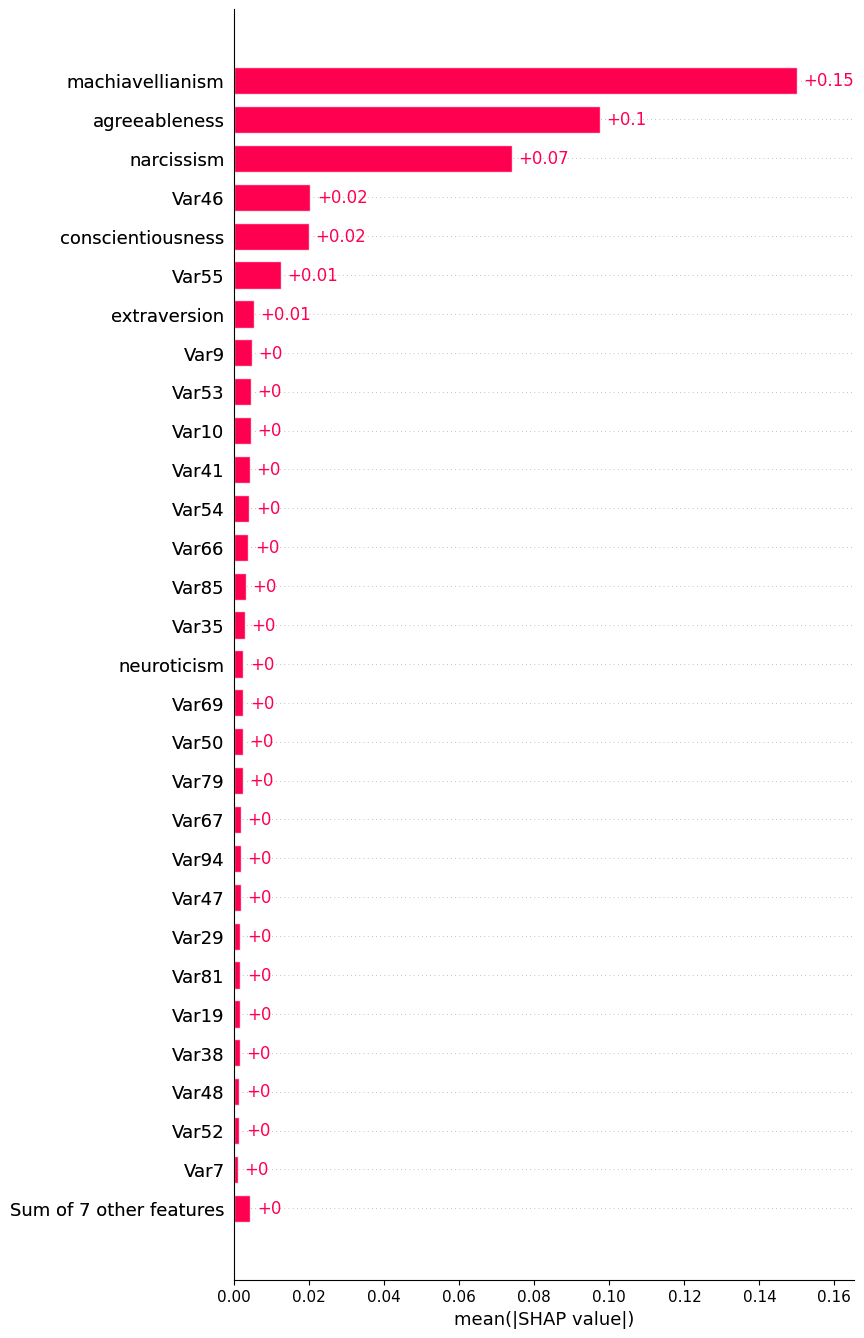

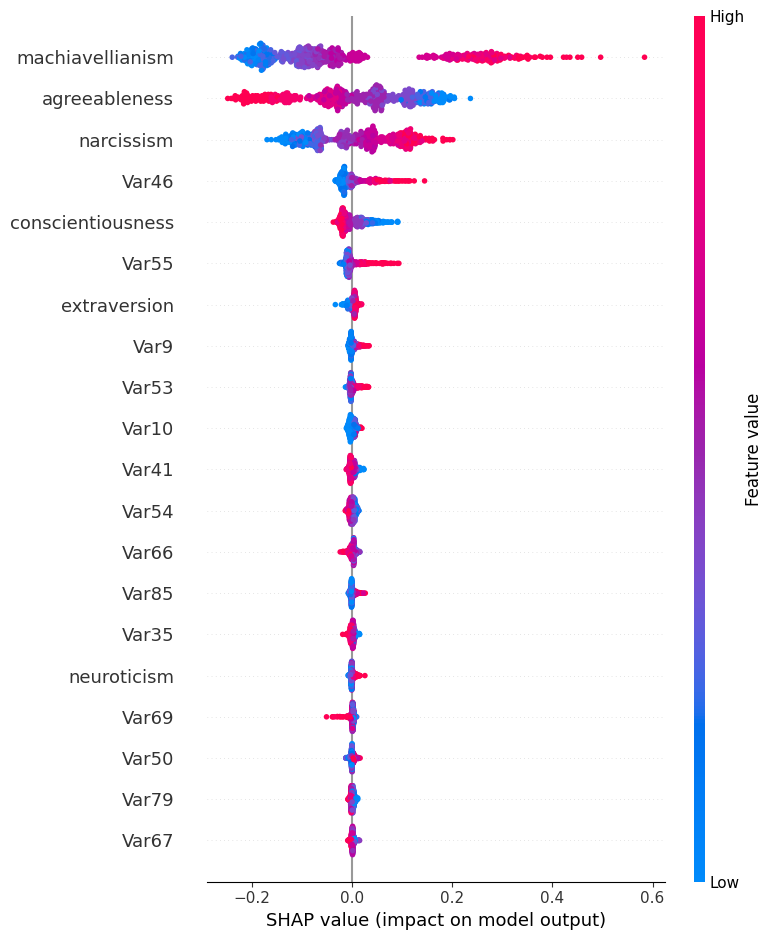

In [21]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test)

shap.plots.bar(shap_values, max_display=30)  # 가장 영향 큰 feature
shap.summary_plot(shap_values, X_test, show=True)


In [22]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy= 'mean')
dummy.fit(X_train , y_train)

print(f"Baseline R²: {dummy.score(X_test, y_test):.4f}")


Baseline R²: -0.0009


In [23]:
lr = LinearRegression()

param_grid = {
    'fit_intercept': [True, False],
    'positive': [False, True]
}

grid_search = GridSearchCV(lr, param_grid , cv = 5 , scoring = 'r2')

grid_search.fit(X_train, y_train)

print("Best Params:", grid_search.best_params_)
best_model = grid_search.best_estimator_


y_pred = best_model.predict(X_test)
r2 = r2_score(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test , y_pred))

print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Best Params: {'fit_intercept': True, 'positive': False}
RMSE: 0.4827
R² Score: 0.3458


In [24]:
Lmodel = LinearRegression()

Lmodel.fit(X_train,y_train)
y_lrpred = Lmodel.predict(X_test)

print("LinearReg RMSE:", np.sqrt(mean_squared_error(y_test, y_lrpred)))
print("LinearReg R²:", r2_score(y_test, y_lrpred))

LinearReg RMSE: 0.48273747736645234
LinearReg R²: 0.34580049159600357


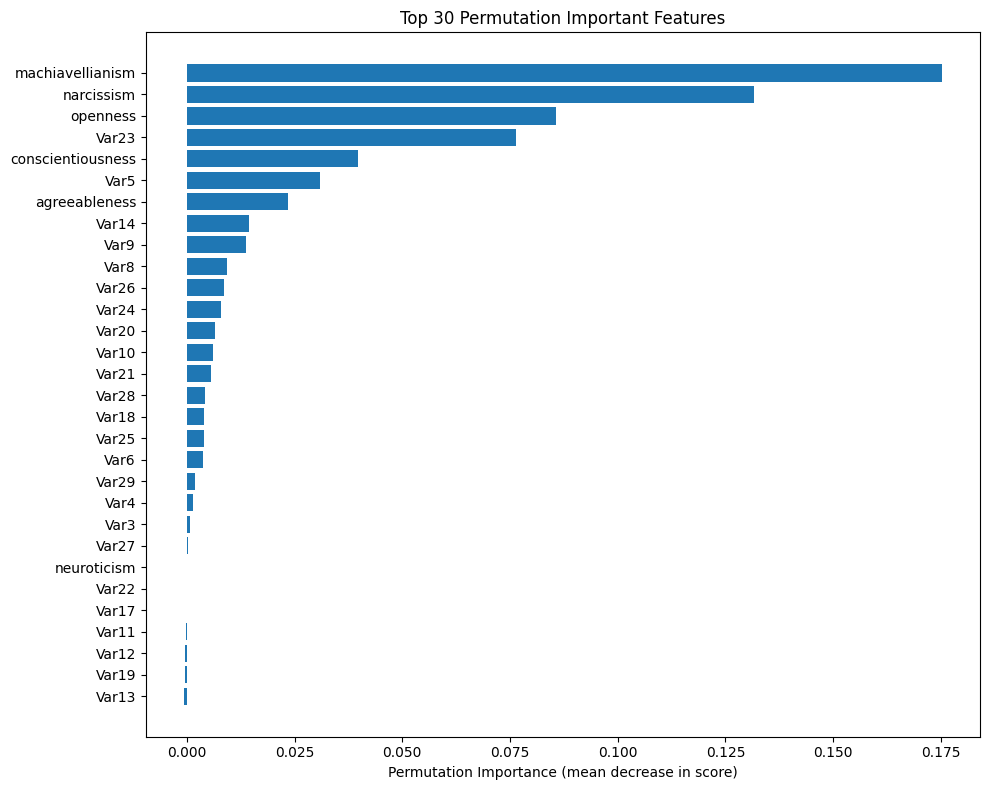

In [25]:
perm = permutation_importance(Lmodel, X_test, y_test , n_repeats = 10)
top_idx = perm.importances_mean.argsort()[::-1][:30]


# 중요도와 feature 이름 정리
importances = perm.importances_mean[top_idx]
feature_names = X.columns[top_idx]

perm_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(perm_df['feature'], perm_df['importance'])
plt.xlabel('Permutation Importance (mean decrease in score)')
plt.title('Top 30 Permutation Important Features')
plt.tight_layout()
plt.show()

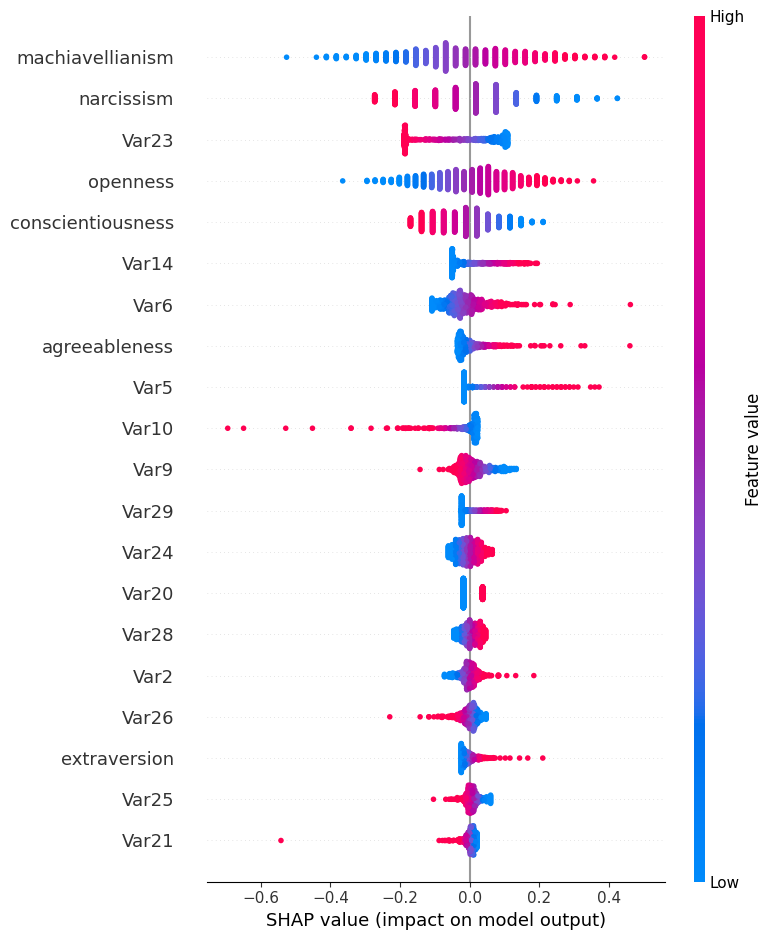

In [26]:
explainer = shap.LinearExplainer(Lmodel, X_train)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=X.columns)


In [27]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR

base_estimators = [
    ('rf',  RandomForestRegressor(n_estimators=100, random_state=42)),
    ('xgb', XGBRegressor(n_estimators=100, random_state=42)),
    ('svr', SVR(C=1.0, epsilon=0.1))
]

meta_estimator = RidgeCV(alphas=[0.1, 1.0, 10.0], cv=5)


stack = StackingRegressor(
    estimators=base_estimators,
    final_estimator=meta_estimator,
    cv=5,
    passthrough=True )

stack.fit(X_train, y_train)
y_pred_stack = stack.predict(X_test)

print("Stacking R² :", r2_score(y_test, y_pred_stack))
print("Stacking RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))



Stacking R² : 0.3495788769359959
Stacking RMSE: 0.48273747736645234
